In [46]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
import MixedEffectsModeling.config as config
from viz_style import apply_style
apply_style()

## 1. Load pool_threshold_sweep.py output

In [47]:
sweep_dir = config.THRESHOLD_SWEEP_DIR
combined_path = sweep_dir / "pool_vs_individual_naive_z.csv"

if combined_path.exists():
    df = pd.read_csv(combined_path)
else:
    parts = sorted(sweep_dir.glob("pool_vs_individual_naive_z_t*.csv"))
    df = pd.concat([pd.read_csv(p) for p in parts], ignore_index=True)

print(f"thresholds present: {sorted(df['threshold'].unique())}")
print(f"rows: {len(df)}, unique genes: {df['gene'].nunique()}")
df.head()

thresholds present: [np.int64(10), np.int64(20), np.int64(30), np.int64(40)]
rows: 3571, unique genes: 1585


,threshold,gene,nz,ind_stage,ind_n_folds_ok,ind_fail_reasons,ind_naive_exceed,ind_naive_fdr_reject_rate,ind_raw_skew,ind_raw_kurtosis,...,pool_obs_zero_frac,pool_pred_zero_frac,pool_zero_diff,pool_pearson_chi2,pool_obs_mean,pool_pred_mean,pool_mean_rel_err,pool_obs_var,pool_pred_var,pool_var_rel_err
0,10,ENSG00000007952.19,6,nbi,0,fold0:not_converged_or_explosion_or_tau2_bound...,NaN,NaN,NaN,NaN,...,0.991342,0.991017,-0.000325,1.825230,0.021645,0.020715,-0.042975,0.093327,0.190371,1.039833
1,10,ENSG00000069764.10,6,nbi,4,fold3:not_converged_or_explosion_or_tau2_bound,0.036036,0.001802,0.087847,0.390533,...,0.991342,0.992223,0.000881,2.729730,0.017316,0.016467,-0.049008,0.054534,0.110499,1.026225
2,10,ENSG00000078898.8,9,nbi,3,fold0:not_converged_or_explosion_or_tau2_bound...,0.036145,0.002410,0.109271,0.543418,...,0.987013,0.991712,0.004699,0.568918,0.018759,0.018058,-0.037368,0.029951,0.143862,3.803239
3,10,ENSG00000096395.12,8,nbi,3,fold2:not_converged_or_explosion_or_tau2_bound...,0.048077,0.002404,0.433885,2.444775,...,0.988456,0.987900,-0.000556,13.481015,0.038961,0.037247,-0.043986,0.441483,0.598824,0.356391
4,10,ENSG00000101074.5,7,nbi,2,fold0:not_converged_or_explosion_or_tau2_bound...,0.021661,0.000000,-0.046549,-0.402710,...,0.989899,0.987824,-0.002075,3.008758,0.038961,0.037206,-0.045043,0.352017,0.596143,0.693504


## 2. Individual (nbi) vs pooled calibration vs nz
ind_* columns don't depend on threshold (same fixed-stage CV baseline reused everywhere), so dedupe to one row per gene. pool_* does depend on threshold -- for this first look, use each gene's *smallest applicable threshold* (the first group it would be pooled into), so both lines are one point per gene and directly comparable.

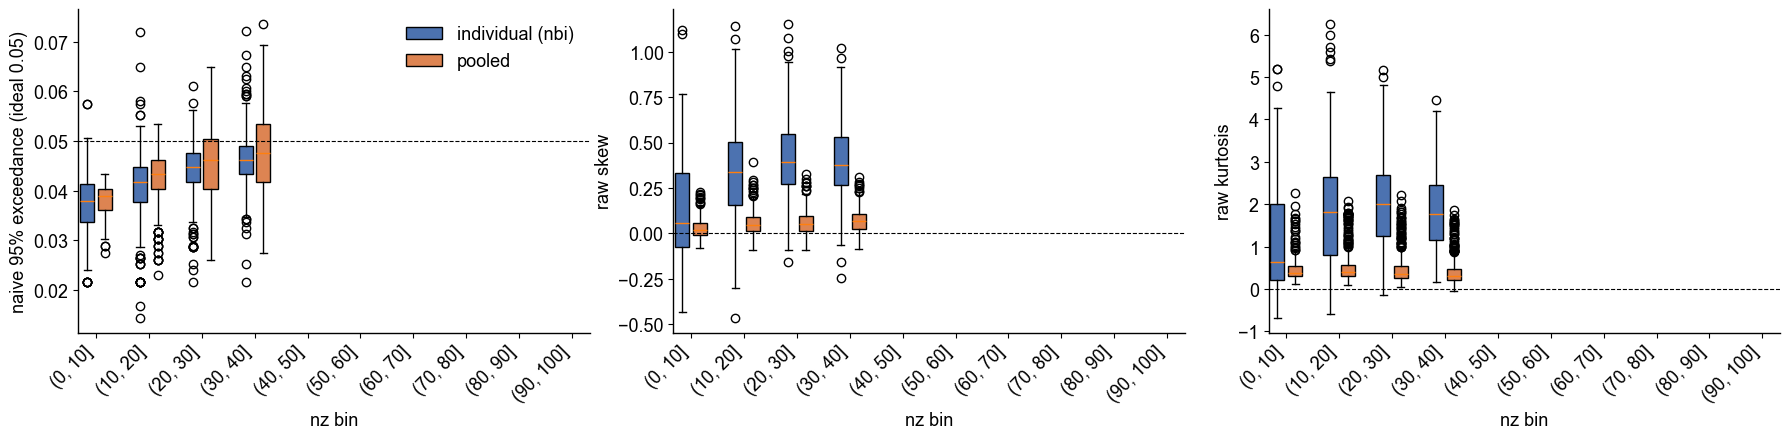

In [48]:
min_t = df.sort_values("threshold").drop_duplicates("gene", keep="first")
cols = [
    "gene", "nz", "ind_n_folds_ok", "ind_naive_exceed", "ind_raw_skew", "ind_raw_kurtosis",
    "pool_n_folds_ok", "pool_naive_exceed", "pool_raw_skew", "pool_raw_kurtosis",
]
ind = min_t[cols].copy()

nz_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
ind["nz_bin"] = pd.cut(ind["nz"], nz_bins)
bins = ind["nz_bin"].cat.categories
positions_ind = np.arange(len(bins)) * 3
positions_pool = positions_ind + 1

panels = [
    ("ind_naive_exceed", "pool_naive_exceed", "naive 95% exceedance (ideal 0.05)", 0.05),
    ("ind_raw_skew", "pool_raw_skew", "raw skew", 0.0),
    ("ind_raw_kurtosis", "pool_raw_kurtosis", "raw kurtosis", 0.0),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (ind_col, pool_col, ylabel, ref) in zip(axes, panels):
    data_ind = [ind.loc[ind["nz_bin"] == b, ind_col].dropna() for b in bins]
    data_pool = [ind.loc[ind["nz_bin"] == b, pool_col].dropna() for b in bins]
    bp_ind = ax.boxplot(data_ind, positions=positions_ind, widths=0.8, patch_artist=True, showfliers=True)
    bp_pool = ax.boxplot(data_pool, positions=positions_pool, widths=0.8, patch_artist=True, showfliers=True)
    for box in bp_ind["boxes"]:
        box.set_facecolor("#4C72B0")
    for box in bp_pool["boxes"]:
        box.set_facecolor("#DD8452")
    ax.axhline(ref, color="black", linestyle="--", linewidth=0.8)
    ax.set_xticks(positions_ind + 0.5)
    ax.set_xticklabels([str(b) for b in bins], rotation=45, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("nz bin")
axes[0].legend([bp_ind["boxes"][0], bp_pool["boxes"][0]], ["individual (nbi)", "pooled"], frameon=False)
plt.tight_layout()
plt.show()

## 2b. PPC (posterior predictive check) vs nz
Raw-Z skew/kurtosis alone doesn't show zero-inflation failure -- PPC (`obs_zero_frac` vs `pred_zero_frac`, `pearson_chi2`) is what previously exposed pooling breaking down on zero fraction. Same one-row-per-gene setup as section 2 (`min_t`).

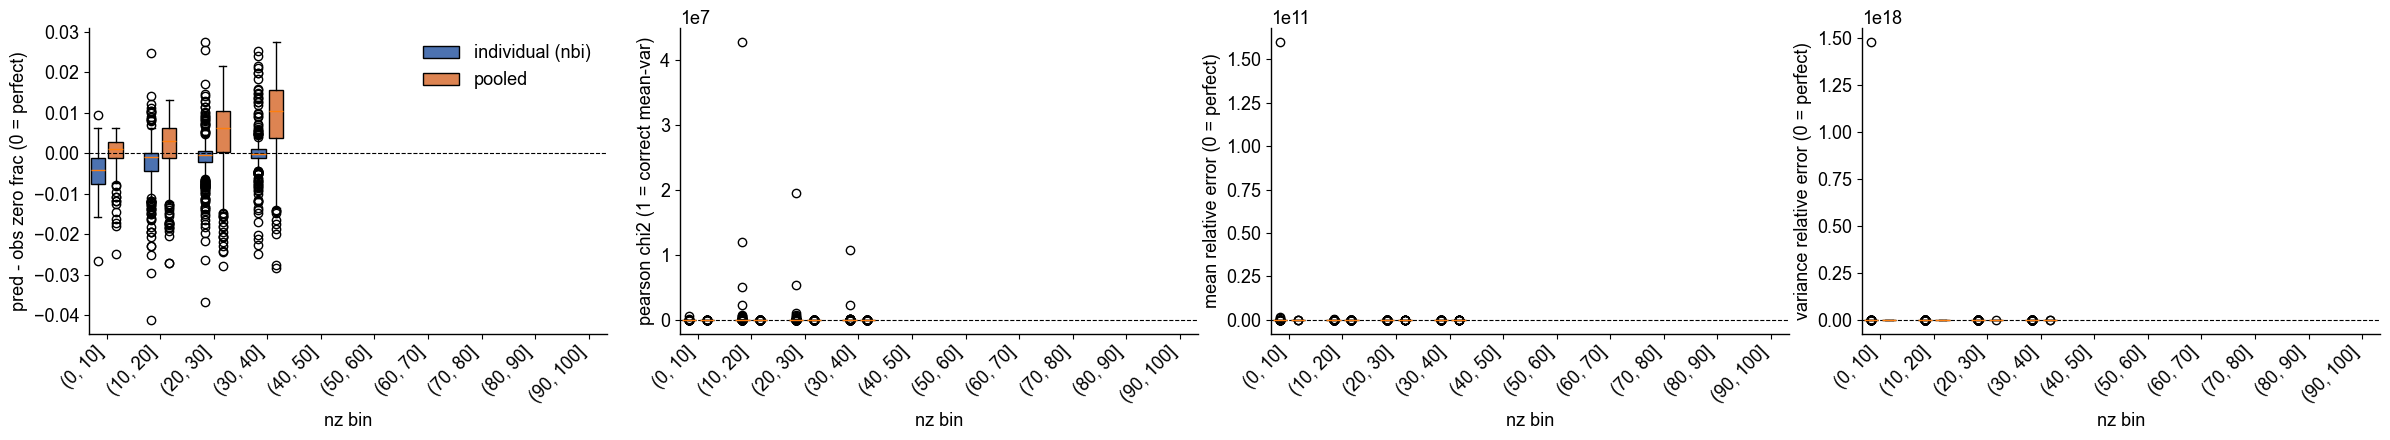

In [49]:
ppc_cols = [
    "gene", "nz", "ind_obs_zero_frac", "ind_pred_zero_frac", "ind_zero_diff", "ind_pearson_chi2",
    "ind_mean_rel_err", "ind_var_rel_err",
    "pool_obs_zero_frac", "pool_pred_zero_frac", "pool_zero_diff", "pool_pearson_chi2",
    "pool_mean_rel_err", "pool_var_rel_err",
]
ppc = min_t[ppc_cols].copy()
ppc["nz_bin"] = pd.cut(ppc["nz"], nz_bins)
bins = ppc["nz_bin"].cat.categories
positions_ind = np.arange(len(bins)) * 3
positions_pool = positions_ind + 1

ppc_panels = [
    ("ind_zero_diff", "pool_zero_diff", "pred - obs zero frac (0 = perfect)", 0.0),
    ("ind_pearson_chi2", "pool_pearson_chi2", "pearson chi2 (1 = correct mean-var)", 1.0),
    ("ind_mean_rel_err", "pool_mean_rel_err", "mean relative error (0 = perfect)", 0.0),
    ("ind_var_rel_err", "pool_var_rel_err", "variance relative error (0 = perfect)", 0.0),
]

fig, axes = plt.subplots(1, 4, figsize=(24, 4.5))
for ax, (ind_col, pool_col, ylabel, ref) in zip(axes, ppc_panels):
    data_ind = [ppc.loc[ppc["nz_bin"] == b, ind_col].dropna() for b in bins]
    data_pool = [ppc.loc[ppc["nz_bin"] == b, pool_col].dropna() for b in bins]
    bp_ind = ax.boxplot(data_ind, positions=positions_ind, widths=0.8, patch_artist=True, showfliers=True)
    bp_pool = ax.boxplot(data_pool, positions=positions_pool, widths=0.8, patch_artist=True, showfliers=True)
    for box in bp_ind["boxes"]:
        box.set_facecolor("#4C72B0")
    for box in bp_pool["boxes"]:
        box.set_facecolor("#DD8452")
    ax.axhline(ref, color="black", linestyle="--", linewidth=0.8)
    ax.set_xticks(positions_ind + 0.5)
    ax.set_xticklabels([str(b) for b in bins], rotation=45, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("nz bin")
axes[0].legend([bp_ind["boxes"][0], bp_pool["boxes"][0]], ["individual (nbi)", "pooled"], frameon=False)
plt.tight_layout()
plt.show()

## 2c. Fold-coverage caveat
`ind_*` metrics in 2/2b are silently distorted two ways: (1) genes where nbi fails all 5 folds get dropped entirely from the boxplots via `dropna()` (pool still shown), (2) genes with partial failure compute `ind_*` only from the folds that *did* converge -- a survivorship-biased, smaller-n subset, not the full held-out set pool is scored on. Both biases favor individual looking better than it should. Show the coverage explicitly instead of letting it stay invisible.

In [50]:
cov = min_t[["gene", "nz", "ind_n_folds_ok", "pool_n_folds_ok"]].copy()
cov["nz_bin"] = pd.cut(cov["nz"], nz_bins)
coverage_table = cov.groupby("nz_bin").agg(
    n_genes=("gene", "size"),
    ind_fully_failed=("ind_n_folds_ok", lambda s: (s == 0).sum()),
    ind_partial_failed=("ind_n_folds_ok", lambda s: ((s > 0) & (s < 5)).sum()),
    ind_fully_converged=("ind_n_folds_ok", lambda s: (s == 5).sum()),
    ind_mean_folds_ok=("ind_n_folds_ok", "mean"),
    pool_fully_converged=("pool_n_folds_ok", lambda s: (s == 5).sum()),
)
coverage_table["ind_fully_failed_pct"] = (coverage_table["ind_fully_failed"] / coverage_table["n_genes"] * 100).round(1)
coverage_table["ind_partial_failed_pct"] = (coverage_table["ind_partial_failed"] / coverage_table["n_genes"] * 100).round(1)
coverage_table

/tmp/ipykernel_183050/126654005.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  coverage_table = cov.groupby("nz_bin").agg(


,n_genes,ind_fully_failed,ind_partial_failed,ind_fully_converged,ind_mean_folds_ok,pool_fully_converged,ind_fully_failed_pct,ind_partial_failed_pct
nz_bin,,,,,,,,
"(0, 10]",214,6,194,14,2.887850,214,2.8,90.7
"(10, 20]",505,0,303,202,3.968317,505,0.0,60.0
"(20, 30]",464,0,156,308,4.525862,464,0.0,33.6
"(30, 40]",402,0,78,324,4.761194,402,0.0,19.4
"(40, 50]",0,0,0,0,NaN,0,NaN,NaN
"(50, 60]",0,0,0,0,NaN,0,NaN,NaN
"(60, 70]",0,0,0,0,NaN,0,NaN,NaN
"(70, 80]",0,0,0,0,NaN,0,NaN,NaN
"(80, 90]",0,0,0,0,NaN,0,NaN,NaN


## 2d. Apples-to-apples: individual fully converged only
Restrict to genes where nbi converged in all 5 folds (`ind_n_folds_ok==5`) -- same full held-out coverage as pool, so no survivorship bias in `ind_*`. If pooling still wins here, the win-rate isn't an artifact of individual's easier subset.

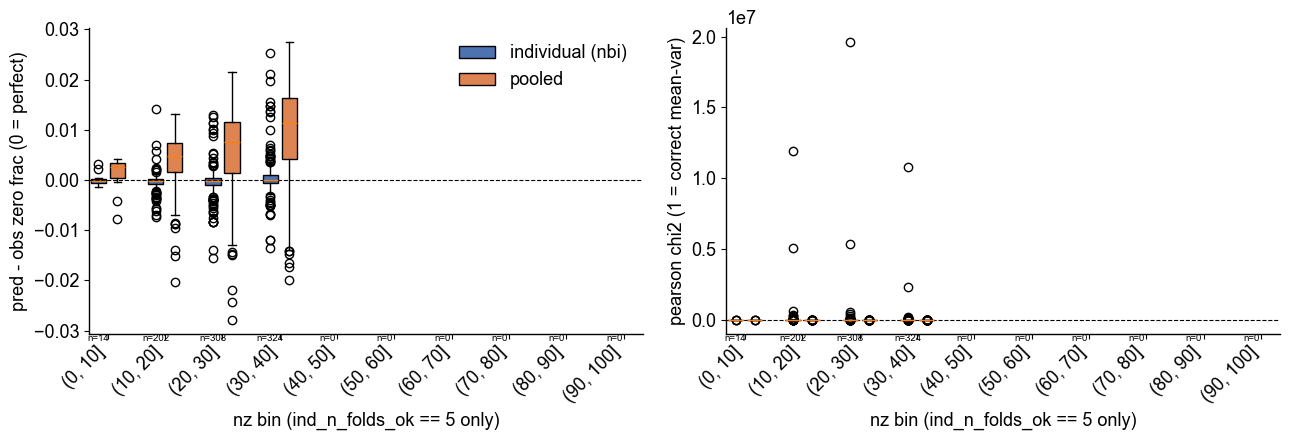

genes with ind fully converged: 848 / 1585


In [51]:
fair = ppc[ppc["gene"].isin(cov.loc[cov["ind_n_folds_ok"] == 5, "gene"])].copy()
bins = fair["nz_bin"].cat.categories
positions_ind = np.arange(len(bins)) * 3
positions_pool = positions_ind + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (ind_col, pool_col, ylabel, ref) in zip(axes, ppc_panels):
    data_ind = [fair.loc[fair["nz_bin"] == b, ind_col].dropna() for b in bins]
    data_pool = [fair.loc[fair["nz_bin"] == b, pool_col].dropna() for b in bins]
    bp_ind = ax.boxplot(data_ind, positions=positions_ind, widths=0.8, patch_artist=True, showfliers=True)
    bp_pool = ax.boxplot(data_pool, positions=positions_pool, widths=0.8, patch_artist=True, showfliers=True)
    for box in bp_ind["boxes"]:
        box.set_facecolor("#4C72B0")
    for box in bp_pool["boxes"]:
        box.set_facecolor("#DD8452")
    for pos, d in zip(positions_ind, data_ind):
        ax.text(pos, ax.get_ylim()[0], f"n={len(d)}", ha="center", va="top", fontsize=7)
    ax.axhline(ref, color="black", linestyle="--", linewidth=0.8)
    ax.set_xticks(positions_ind + 0.5)
    ax.set_xticklabels([str(b) for b in bins], rotation=45, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("nz bin (ind_n_folds_ok == 5 only)")
axes[0].legend([bp_ind["boxes"][0], bp_pool["boxes"][0]], ["individual (nbi)", "pooled"], frameon=False)
plt.tight_layout()
plt.show()
print(f"genes with ind fully converged: {len(fair)} / {len(ppc)}")

## 2e. Which genes does pooling actually distort?
Worst pooled mean-var fits, with `ind_n_folds_ok` shown so a distorted gene backed by a full-coverage individual fit (fair comparison) is distinguished from one backed by a partial/failed individual fit (comparison not meaningful).

In [52]:
worst = ppc.merge(cov[["gene", "ind_n_folds_ok", "pool_n_folds_ok"]], on="gene")
worst["pool_chi2_dev"] = (worst["pool_pearson_chi2"] - 1).abs()
worst = worst.sort_values("pool_chi2_dev", ascending=False)
print("Top 20 genes by |pool_pearson_chi2 - 1| (worst pooled mean-var fit):")
worst[["gene", "nz", "ind_n_folds_ok", "pool_n_folds_ok",
      "ind_pearson_chi2", "pool_pearson_chi2", "ind_zero_diff", "pool_zero_diff"]].head(20)

Top 20 genes by |pool_pearson_chi2 - 1| (worst pooled mean-var fit):


,gene,nz,ind_n_folds_ok,pool_n_folds_ok,ind_pearson_chi2,pool_pearson_chi2,ind_zero_diff,pool_zero_diff
148,ENSG00000133105.8,9,3,5,5.998454e+05,5511.842587,-0.006766,-0.014568
292,ENSG00000165887.13,10,1,5,5.078071e-03,5166.988807,-0.026541,-0.024913
127,ENSG00000184351.8,8,0,5,NaN,3533.199017,NaN,-0.017858
1112,ENSG00000284188.3,27,4,5,8.557809e+04,1643.283410,0.001012,-0.012840
860,ENSG00000173572.13,25,5,5,1.962568e+07,819.763091,-0.002083,-0.027812
642,ENSG00000102970.11,12,3,5,1.137306e+02,819.121726,-0.011798,-0.027048
1418,ENSG00000186086.19,33,5,5,2.066697e+04,627.123229,-0.000215,-0.016519
1352,ENSG00000174567.9,37,5,5,2.996584e+03,625.828848,0.000771,-0.002897
570,ENSG00000267157.1,13,5,5,1.745831e+04,606.651227,0.000259,-0.015060
277,ENSG00000170523.3,15,4,5,6.544348e+02,602.322117,-0.002557,-0.007090


## 3. Fold-level convergence: individual vs pooled
`n_folds_ok` out of 5 -- how often each route actually converges, not just how well-calibrated the successful folds look.

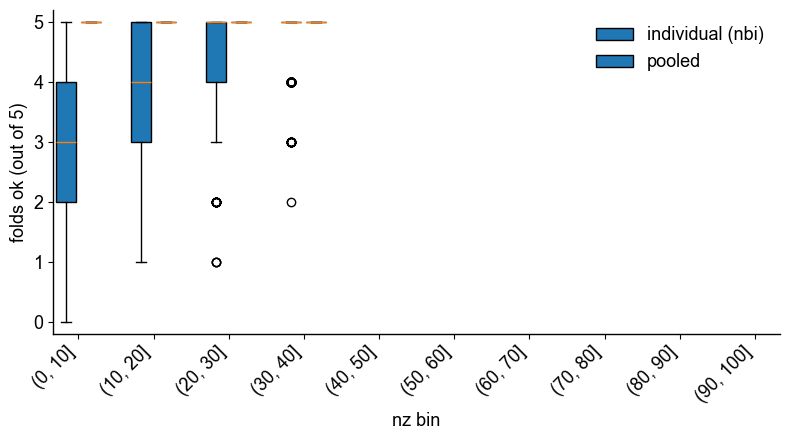

In [53]:
bins = ind["nz_bin"].cat.categories
positions_ind = np.arange(len(bins)) * 3
positions_pool = positions_ind + 1

data_ind = [ind.loc[ind["nz_bin"] == b, "ind_n_folds_ok"].dropna() for b in bins]
data_pool = [ind.loc[ind["nz_bin"] == b, "pool_n_folds_ok"].dropna() for b in bins]

fig, ax = plt.subplots(figsize=(8, 4.5))
bp_ind = ax.boxplot(data_ind, positions=positions_ind, widths=0.8, patch_artist=True)
bp_pool = ax.boxplot(data_pool, positions=positions_pool, widths=0.8, patch_artist=True)

ax.set_xticks(positions_ind + 0.5)
ax.set_xticklabels([str(b) for b in bins], rotation=45, ha="right")
ax.set_ylabel("folds ok (out of 5)")
ax.set_xlabel("nz bin")
ax.set_ylim(-0.2, 5.2)
ax.legend([bp_ind["boxes"][0], bp_pool["boxes"][0]], ["individual (nbi)", "pooled"], frameon=False)
plt.tight_layout()
plt.show()